https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

In [4]:
movie = pd.read_csv('./dataset/movie/movies_metadata.csv')

In [5]:
movie.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.",17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications', 'id': 10201}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",NaN,15602,tt0113228,en,Grumpier Old Men,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming the locals who worry she'll scare the fish away. But she's less interested in seafood than she is in cooking up a hot time with Max.",11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, Glo and Robin talk it all out, determined to find a better way to breathe.",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,"[{'name': 'Twentieth Century Fox Film Corporation', 'id': 306}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself... and never let you forget it.,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg'

In [6]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [7]:
movie = movie.dropna(subset=['overview'])

In [8]:
movie = movie.drop_duplicates(subset=['overview'])

In [10]:
movie = movie.iloc[:20000,:]

In [11]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 20184
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  20000 non-null  object 
 1   belongs_to_collection  2405 non-null   object 
 2   budget                 20000 non-null  object 
 3   genres                 20000 non-null  object 
 4   homepage               3091 non-null   object 
 5   id                     20000 non-null  object 
 6   imdb_id                19994 non-null  object 
 7   original_language      19999 non-null  object 
 8   original_title         20000 non-null  object 
 9   overview               20000 non-null  object 
 10  popularity             19998 non-null  object 
 11  poster_path            19913 non-null  object 
 12  production_companies   19999 non-null  object 
 13  production_countries   19999 non-null  object 
 14  release_date           19984 non-null  object 
 15  revenue

In [12]:
print('overview 열의 결측값의 수:',movie['overview'].isnull().sum())

overview 열의 결측값의 수: 0


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movie['overview'])
print('TF-IDF 행렬의 크기(shape) :',tfidf_matrix.shape)

TF-IDF 행렬의 크기(shape) : (20000, 47734)


In [ ]:
tfidf_vt = TfidfVectorizer( stop_words=stop_words_list , lowercase=True
                            , token_pattern=r'\b[a-z]{2,}\b')
res = tfidf_vt.fit_transform(movie['overview'])  #---------- 1D
#print(tfidf_vt.vocabulary_)

print(res.shape)
print(tfidf_vt.get_feature_names_out())

tfidf = pd.DataFrame(res.toarray(), columns=tfidf_vt.get_feature_names_out(), index=movie['title'])
tfidf

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print('코사인 유사도 연산 결과 :',cosine_sim.shape)

코사인 유사도 연산 결과 : (20000, 20000)


In [16]:
title_to_index = dict(zip(movie['title'], movie.index))

# 영화 제목 Father of the Bride Part II의 인덱스를 리턴
idx = title_to_index['Father of the Bride Part II']
print(idx)

4


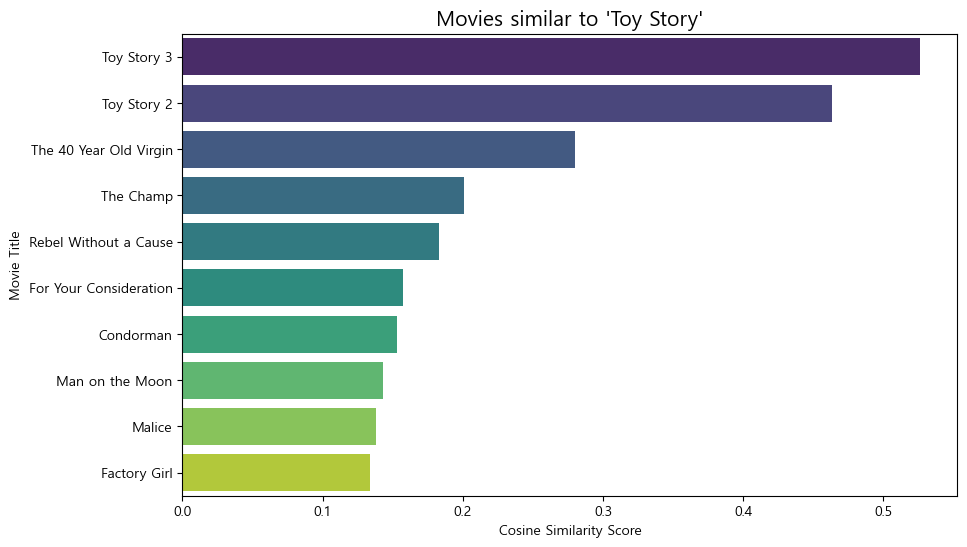

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_similarity(title, cosine_sim=cosine_sim, df=movie):
    # 1. 영화 제목을 통해 인덱스 추출
    indices = pd.Series(df.index, index=df['title']).drop_duplicates()
    idx = indices[title]

    # 2. 모든 영화와의 유사도 구하기
    sim_scores = list(enumerate(cosine_sim[idx]))

    # 3. 유사도 순으로 정렬 (자기 자신 제외)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11] # 상위 10개

    # 4. 영화 인덱스와 점수 추출
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    movie_titles = df['title'].iloc[movie_indices].values

    # 5. 시각화
    plt.figure(figsize=(10, 6))
    sns.barplot(x=scores, y=movie_titles, palette='viridis')
    plt.title(f"Movies similar to '{title}'", fontsize=15)
    plt.xlabel("Cosine Similarity Score")
    plt.ylabel("Movie Title")
    plt.show()

# 테스트: 'Toy Story'와 유사한 영화들 비교
plot_similarity('Toy Story')

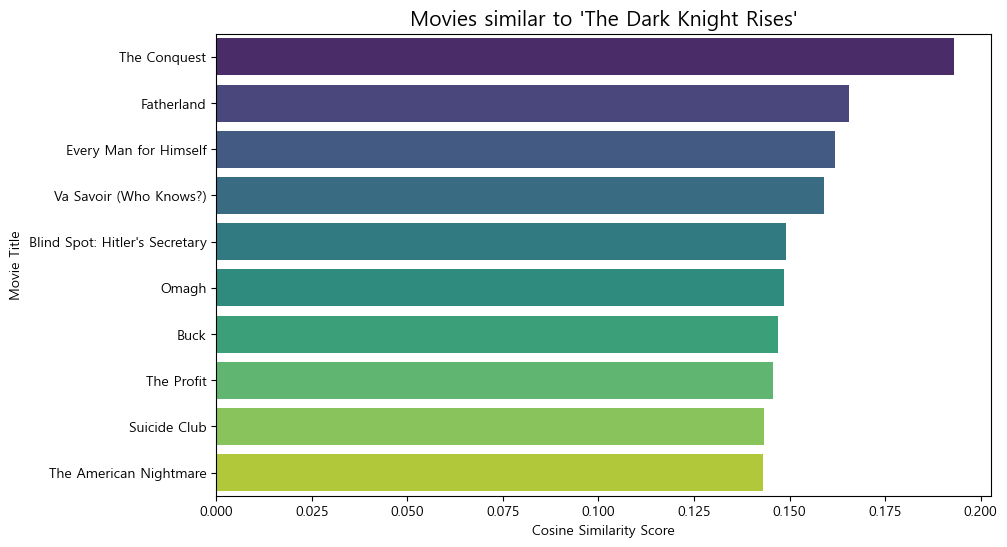

In [20]:
plot_similarity('The Dark Knight Rises')

[방법1] Tokenizer 토큰화: 사전 인덱스 기반

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

corpus = ['나는 고양이를 좋아한다', '나는 강아지를 좋아한다']

# 1. 사전 구축 및 인덱스 기반 벡터화
vectorizer = CountVectorizer()
count_matrix = vectorizer.fit_transform(corpus)

# 2. 결과 확인 (사전 인덱스 확인)
vocab = vectorizer.vocabulary_
print(f"사전 인덱스: {vocab}")

# 3. 코사인 유사도 계산
count_sim = cosine_similarity(count_matrix, count_matrix)
print(f"인덱스 기반 유사도: \n{count_sim}")

사전 인덱스: {'나는': 2, '고양이를': 1, '좋아한다': 3, '강아지를': 0}
인덱스 기반 유사도: 
[[1.         0.66666667]
 [0.66666667 1.        ]]


In [25]:
# !pip install sentence-transformers

In [26]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 1. 사전 학습된 임베딩 모델 로드 (한국어 지원 모델)
model = SentenceTransformer('jhgan/ko-sroberta-multitask')

corpus = ['나는 고양이를 좋아한다', '나는 강아지를 좋아한다']

# 2. 문장을 밀집 벡터(Dense Vector)로 변환
embedding_matrix = model.encode(corpus)

# 3. 코사인 유사도 계산
embedding_sim = cosine_similarity(embedding_matrix, embedding_matrix)
print(f"임베딩 기반 유사도: \n{embedding_sim}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

임베딩 기반 유사도: 
[[0.9999997  0.29527152]
 [0.29527152 0.9999999 ]]
